In [1]:
#Importações
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Ler o arquivo Excel
df = pd.read_csv("C:/Users/Antenor/Desktop/Coffe_sales.csv")
df


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


In [ ]:
#descobrir se existe numeros faltantes
df.isnull().sum()
#descobrir se existe valores duplicados
df.duplicated().sum()
#descobrir se existe valores duplicados
df.duplicated().sum()


In [3]:
import numpy as np

# Gerar 1000 user_ids únicos aleatórios (por exemplo: USER-0000, USER-0001, ..., USER-0999)
user_ids = [f'USER-{i:04d}' for i in range(1000)]

# Atribuir um user_id a cada linha do DataFrame, amostrando aleatoriamente (com reposição)
df['user_id'] = np.random.choice(user_ids, size=len(df), replace=True)

In [4]:
df['user_id'].value_counts()


user_id
USER-0654    10
USER-0989    10
USER-0367    10
USER-0181    10
USER-0281    10
             ..
USER-0200     1
USER-0015     1
USER-0247     1
USER-0172     1
USER-0413     1
Name: count, Length: 977, dtype: int64

In [5]:
# Calcular o tempo médio (em dias) para cada user_id retornar e fazer uma nova compra

# Garantir que a coluna 'Date' está em datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar por user_id e Date
df_sorted = df.sort_values(['user_id', 'Date'])

# Calcular o tempo entre compras consecutivas para cada usuário
df_sorted['time_since_last_purchase'] = df_sorted.groupby('user_id')['Date'].diff()

# Exemplo: mostrar a média (em dias) de tempo entre compras por usuário
user_return_times = df_sorted.groupby('user_id')['time_since_last_purchase'].mean().dt.days

# Mostrar os primeiros exemplos
print(user_return_times.head(10))

# Se quiser análise geral:
overall_avg_days = user_return_times.mean()
print(f"Média (em dias) para um user_id retornar e comprar novamente: {overall_avg_days:.2f} dias")

# Calcular a média de retorno para cada user_id e adicionar ao DataFrame df na coluna 'media_retorno'
# A média está em dias (pode ser float)

# Calculando a média de retorno em dias para cada user_id
media_retorno_por_user = df_sorted.groupby('user_id')['time_since_last_purchase'].mean().dt.days

# Mapear a média de retorno para cada user_id na tabela df (juntando pelo user_id)
df['media_retorno'] = df['user_id'].map(media_retorno_por_user)

user_id
USER-0000     92.0
USER-0001     65.0
USER-0002     49.0
USER-0003    136.0
USER-0004    181.0
USER-0005     39.0
USER-0006     60.0
USER-0007     75.0
USER-0008     65.0
USER-0009     92.0
Name: time_since_last_purchase, dtype: float64
Média (em dias) para um user_id retornar e comprar novamente: 82.06 dias


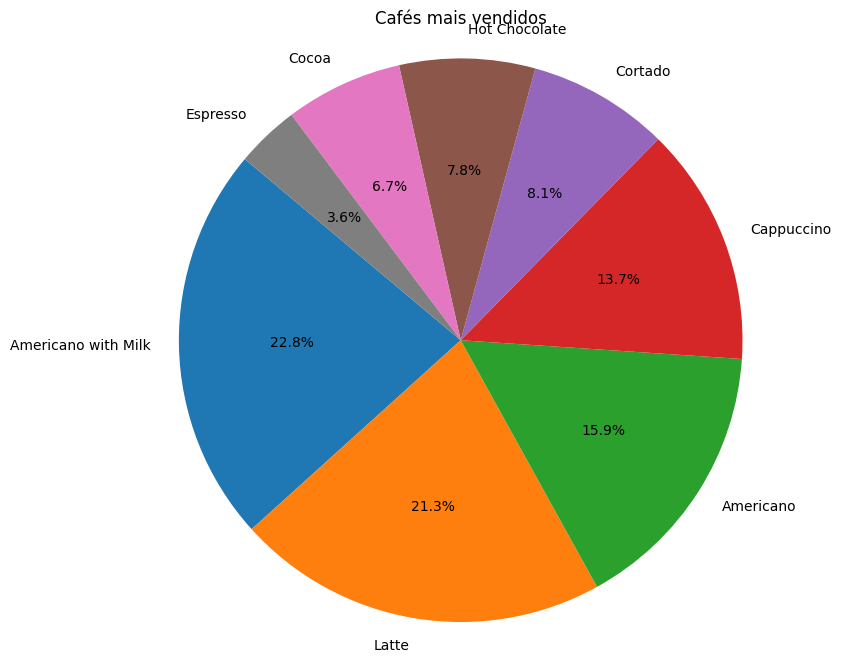

In [6]:


# Calcular a contagem de cada tipo de café vendido
coffee_counts = df['coffee_name'].value_counts()

# Plotar o gráfico de pizza (pie chart) dos cafés mais vendidos
plt.figure(figsize=(8, 8))
plt.pie(coffee_counts, labels=coffee_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Cafés mais vendidos')
plt.axis('equal')  # Mantém o gráfico como círculo
plt.show()

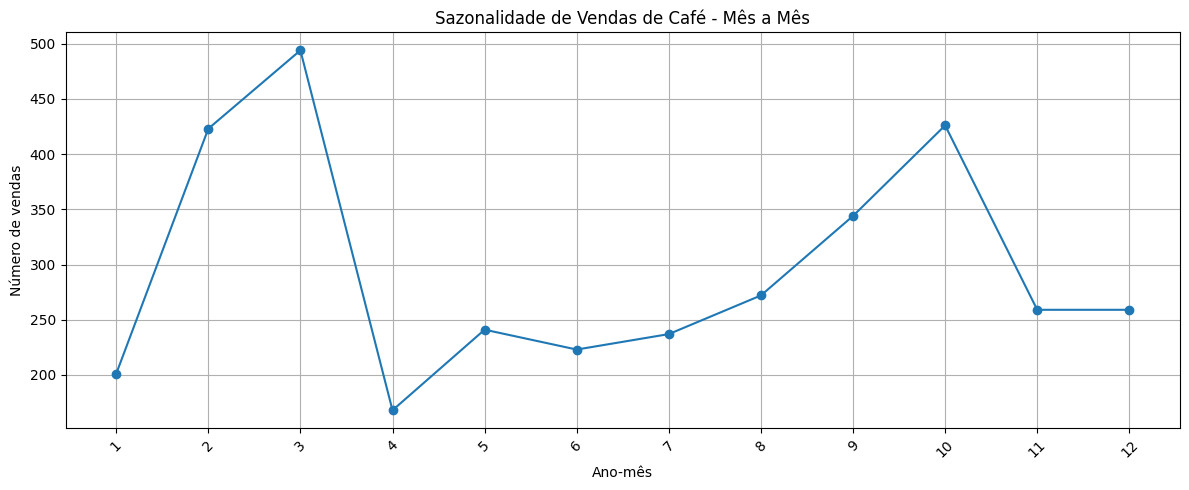

In [7]:
# Gráfico de sazonalidade de vendas de café mês a mês

# Contar o total de vendas por mês/ano

vendas_mensais = df.groupby('Monthsort').size()

# Converter AnoMes para string para melhor visualização no eixo x
vendas_mensais.index = vendas_mensais.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(vendas_mensais.index, vendas_mensais.values, marker='o')
plt.xticks(rotation=45)
plt.title('Sazonalidade de Vendas de Café - Mês a Mês')
plt.xlabel('Ano-mês')
plt.ylabel('Número de vendas')
plt.tight_layout()
plt.grid(True)
plt.show()

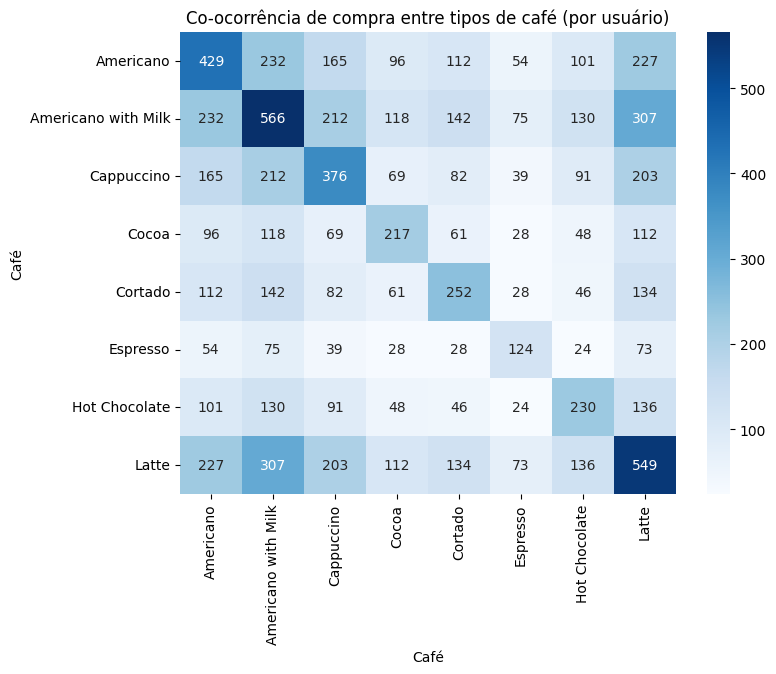

Matriz porcentual de co-compra entre cafés (linhas: café base, colunas: café também comprado):


coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
coffee_name,,,,,,,,
Americano,1.00,0.54,0.38,0.22,0.26,0.13,0.24,0.53
Americano with Milk,0.41,1.00,0.37,0.21,0.25,0.13,0.23,0.54
Cappuccino,0.44,0.56,1.00,0.18,0.22,0.10,0.24,0.54
Cocoa,0.44,0.54,0.32,1.00,0.28,0.13,0.22,0.52
Cortado,0.44,0.56,0.33,0.24,1.00,0.11,0.18,0.53
Espresso,0.44,0.60,0.31,0.23,0.23,1.00,0.19,0.59
Hot Chocolate,0.44,0.57,0.40,0.21,0.20,0.10,1.00,0.59
Latte,0.41,0.56,0.37,0.20,0.24,0.13,0.25,1.00


In [8]:
# Análise de "quem compra um tipo de café também compra outro"

# Vamos criar uma tabela cruzada (co-ocorrência) dos tipos de café por user_id
# Ela mostra quantos usuários compraram cada par de cafés diferentes

import itertools

# Cria uma tabela user_id x coffee_name (1 se comprou, 0 caso contrário)
user_cafe = pd.crosstab(df['user_id'], df['coffee_name'])

# Matriz de co-compra
co_compra = pd.DataFrame(0, index=user_cafe.columns, columns=user_cafe.columns)

# Para cada usuário, incrementa para cada par de cafés comprados por esse usuário
for row in user_cafe.itertuples(index=False):
    cafes_comprados = user_cafe.columns[[i for i, v in enumerate(row) if v > 0]]
    for combo in itertools.combinations(cafes_comprados, 2):
        co_compra.loc[combo[0], combo[1]] += 1
        co_compra.loc[combo[1], combo[0]] += 1  # simétrico

# Quantos usuários compraram apenas cada café (diagonal: total individual)
for cafe in user_cafe.columns:
    co_compra.loc[cafe, cafe] = (user_cafe[cafe] > 0).sum()

# Visualização: heatmap de co-ocorrência
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(co_compra, annot=True, cmap="Blues", fmt="d")
plt.title("Co-ocorrência de compra entre tipos de café (por usuário)")
plt.xlabel("Café")
plt.ylabel("Café")
plt.show()

# Exemplo extra: mostrar % de usuários de cada café que também compraram outro café
# (Por exemplo: dos que compraram Espresso, quantos também compraram Latte)
percent_co = co_compra.div(co_compra.values.diagonal(), axis=0).fillna(0).round(2)
print("Matriz porcentual de co-compra entre cafés (linhas: café base, colunas: café também comprado):")
display(percent_co)

Média de vendas por hora do dia para cada tipo de café (quantidade de compras):


coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
hour_of_day,,,,,,,,
6,2,2,1,0,0,0,0,0
7,12,18,20,4,2,2,0,30
8,48,51,22,15,41,6,5,47
9,27,94,23,15,33,9,7,34
10,59,101,28,8,33,12,21,66
11,71,65,28,16,34,15,16,38
12,55,55,29,14,20,13,9,46
13,46,56,30,11,24,7,10,41
14,43,43,36,17,16,10,13,47


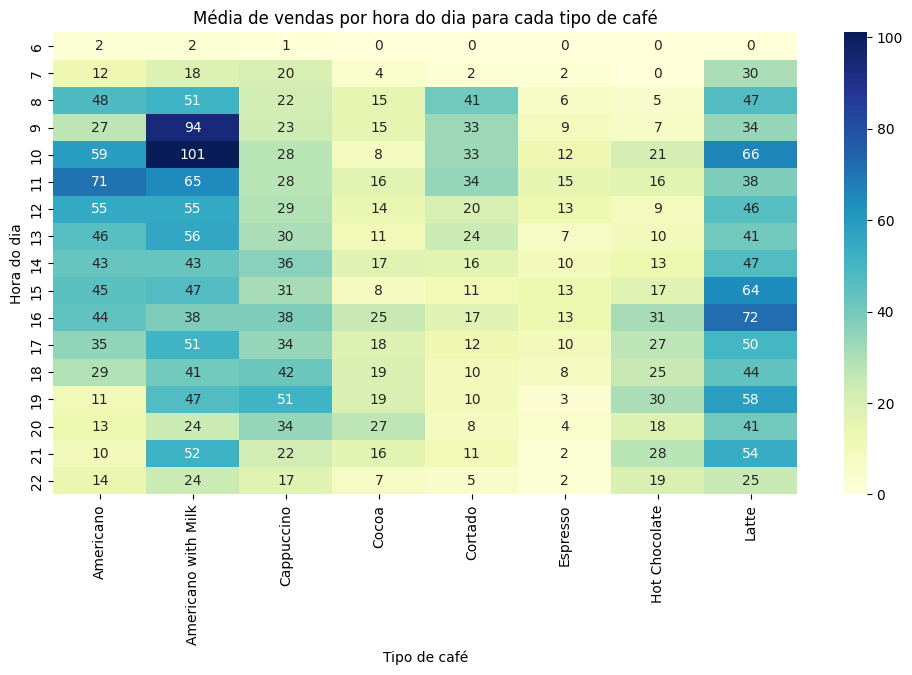

In [9]:
# Média de vendas (quantidade) por hora do dia para cada tipo de café

# Garante que a coluna 'hour_of_day' está presente e correta
if 'hour_of_day' not in df.columns:
    df['hour_of_day'] = df['Time'].dt.hour

# Calcula a média de vendas por hora para cada tipo de café
media_vendas_hora_cafe = df.groupby(['coffee_name', 'hour_of_day']).size().unstack(fill_value=0)

# Transpõe para facilitar visualização (opcional)
media_vendas_hora_cafe = media_vendas_hora_cafe.T

print("Média de vendas por hora do dia para cada tipo de café (quantidade de compras):")
display(media_vendas_hora_cafe)

# Visualização opcional: Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(media_vendas_hora_cafe, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Média de vendas por hora do dia para cada tipo de café")
plt.xlabel("Tipo de café")
plt.ylabel("Hora do dia")
plt.show()

In [10]:
# Criar coluna 'compra_recente' = True se a compra foi feita a menos de 3 semanas da última compra de cada user_id

# Para cada user_id, calcular a diferença entre a data da compra e a última compra desse user
df = df.sort_values(['user_id', 'Date'])  # garantir ordenação
df['dias_desde_ultima_compra'] = df.groupby('user_id')['Date'].diff().dt.days

# Para a primeira compra de cada usuário (diff = NaN), pode preencher com valor alto/nan conforme sua lógica
df['dias_desde_ultima_compra'] = df['dias_desde_ultima_compra'].fillna(0)




In [11]:
# Cria coluna com a frequencia de compras por user_id, onde 1 é a primeira compra e 2 é a segunda compra e assim por diante
df['frequencia_compras'] = df.groupby('user_id')['Date'].rank(method='dense', ascending=True)


In [12]:
#criar coluna com a media de valor gasto por user_id
df['media_valor_gasto'] = df.groupby('user_id')['money'].transform('mean')
df
#criar coluna com a media de valor gasto por user_id



,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,user_id,media_retorno,dias_desde_ultima_compra,frequencia_compras,media_valor_gasto
722,18,card,27.92,Americano,Night,Mon,Jun,1,6,2024-06-17,18:51:19.631000,USER-0000,92.0,0.0,1.0,31.350
2341,14,card,35.76,Hot Chocolate,Afternoon,Sat,Nov,6,11,2024-11-30,14:05:58.078000,USER-0000,92.0,166.0,2.0,31.350
3065,20,card,35.76,Hot Chocolate,Night,Tue,Feb,2,2,2025-02-18,20:58:12.599000,USER-0000,92.0,80.0,3.0,31.350
3517,13,card,25.96,Americano,Afternoon,Fri,Mar,5,3,2025-03-21,13:02:48.347000,USER-0000,92.0,31.0,4.0,31.350
181,10,card,38.70,Latte,Morning,Tue,Apr,2,4,2024-04-02,10:01:14.022000,USER-0001,65.0,0.0,1.0,36.985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651,9,card,30.86,Americano with Milk,Morning,Fri,Jan,5,1,2025-01-10,09:16:36.498000,USER-0997,103.0,67.0,4.0,33.310
636,21,card,32.82,Americano with Milk,Night,Thu,Jun,4,6,2024-06-06,21:19:30.436000,USER-0998,NaN,0.0,1.0,32.820
905,16,card,32.82,Latte,Afternoon,Fri,Jul,5,7,2024-07-19,16:37:35.808000,USER-0999,37.0,0.0,1.0,33.800
1328,8,card,32.82,Latte,Morning,Mon,Sep,1,9,2024-09-02,08:51:33.148000,USER-0999,37.0,45.0,2.0,33.800


In [13]:
# Aplicar encoding na coluna 'Weekday'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Weekday'] = le.fit_transform(df['Weekday'])

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selecionar variáveis numéricas para segmentação (ajuste conforme necessário)
segmentation_columns = ['dias_desde_ultima_compra', 'frequencia_compras', 'media_valor_gasto', 'hour_of_day', 'Weekday'  ]
X = df[segmentation_columns].fillna(0)

# Escalar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans: vamos usar 4 segmentos como exemplo (pode ajustar n_clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Visualização rápida dos grupos
print(df.groupby('cluster_kmeans')[segmentation_columns].mean())

                dias_desde_ultima_compra  frequencia_compras  \
cluster_kmeans                                                 
0                              26.330717            1.906951   
1                              41.932119            5.382450   
2                              35.426270            2.311029   
3                              22.491156            1.956463   
4                             169.628684            2.721022   

                media_valor_gasto  hour_of_day   Weekday  
cluster_kmeans                                            
0                       32.902076    18.602018  2.900224  
1                       31.649651    14.625828  3.432119  
2                       31.021967    11.123916  0.995043  
3                       30.552822    11.695238  4.874830  
4                       32.002923    14.375246  3.133595  


Cluster 0 — “Clientes Perdidos / Churn”

| Métrica                  | Valor  |
| ------------------------ | ------ |
| dias desde última compra | 170    |
| frequência               | baixa  |
| ticket                   | normal |
| horário                  | tarde  |

Cluster 1 — “Clientes de rotina matinal”

| Métrica    | Valor |
| ---------- | ----- |
| recência   | 33    |
| frequência | média |
| horário    | 11h   |
| weekday    | ~1    |

Cluster 2 — “Clientes de fim de semana”

| Métrica    | Valor |
| ---------- | ----- |
| weekday    | 4.84  |
| horário    | 11h   |
| frequência | baixa |

Cluster 3 — “Clientes Noturnos”

| Métrica    | Valor        |
| ---------- | ------------ |
| horário    | 18.6         |
| frequência | ~2           |
| gasto      | maior ticket |

Cluster 4 — “Clientes Fiéis”

| Métrica    | Valor  |
| ---------- | ------ |
| frequência | 5.5    |
| recência   | 44     |
| gasto      | normal |



In [15]:
#função para decidir a campanha para cada cluster
def decide_campaign(cluster):

    campaigns = {
        0: "coupon_30",
        1: "morning_push",
        2: "weekend_promo",
        3: "night_push",
        4: "loyalty_reward"
    }

    return campaigns.get(cluster, "default_campaign")

In [16]:
df['campaign'] = df['cluster_kmeans'].apply(decide_campaign)

In [17]:
df.dtypes

hour_of_day                          int64
cash_type                           object
money                              float64
coffee_name                         object
Time_of_Day                         object
Weekday                              int64
Month_name                          object
Weekdaysort                          int64
Monthsort                            int64
Date                        datetime64[ns]
Time                                object
user_id                             object
media_retorno                      float64
dias_desde_ultima_compra           float64
frequencia_compras                 float64
media_valor_gasto                  float64
cluster_kmeans                       int32
campaign                            object
dtype: object

In [18]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['cash_type', 'coffee_name', 'Time_of_Day', 'Month_name']

label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features para classificação (removendo o target 'cluster_kmeans' e outras colunas não numéricas)
features_classification = [
    col for col in df.columns
    if col not in ['cluster_kmeans', 'campaign', 'user_id',  'Time', 'Date']
]

X_cls = df[features_classification].fillna(0)
y_cls = df['cluster_kmeans']

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# Instanciar o modelo
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, enable_categorical=True)
xgb.fit(X_train, y_train)

# Previsões
y_pred = xgb.predict(X_test)

# Relatório de classificação
print(classification_report(y_test, y_pred))

c:\Users\Antenor\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:10:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.97      0.98      0.97       179
           1       0.97      0.98      0.97       121
           2       0.96      0.98      0.97       161
           3       0.98      0.95      0.97       147
           4       0.96      0.94      0.95       102

    accuracy                           0.97       710
   macro avg       0.97      0.96      0.97       710
weighted avg       0.97      0.97      0.97       710



In [20]:
#descobrir se existe numeros faltantes
df.isnull().sum()
#descobrir se existe valores duplicados
df.duplicated().sum()
#descobrir se existe valores duplicados
df.duplicated().sum()


np.int64(0)